# VIX/VIX3M Ratio

1. `比值 > 1.10` — **恐慌区**：
   - 当前恐慌指数近月与远月的比值为 1.20，处于恐慌区。
   - 这表明市场情绪出现短期恐慌情绪的急剧升温，典型特征为市场陷入危机或面临剧烈抛售压力。
2. `1.00 < 比值 <= 1.10` — **恐惧区**：
   - 当前恐慌指数近月与远月的比值为 1.05，处于恐惧区。
   - 这反映出市场正处于防御性避险状态，常见特征包括剧烈波动与不确定性上升（例如宏观事件干扰）。
3. `0.90 < 比值 <= 1.00` — **中性区**：
   - 当前恐慌指数近月与远月的比值为 0.95，处于中性区。
   - 说明市场情绪偏向观望或分歧，行情多表现为横盘整理或震荡波动。
4. `0.80 < 比值 <= 0.90` — **平稳区**：
   - 当前恐慌指数近月与远月的比值为 0.85，处于平稳区。
   - 反映出市场情绪趋于安逸，波动率受到抑制，整体倾向偏多。
5. `比值 <= 0.80` — **自满区**：
   - 当前恐慌指数近月与远月的比值为 0.75，处于自满区。
   - 市场可能出现过度乐观情绪，常见于行情进入末升段，甚至出现“融涨”迹象。

## Contents

- [Configuration](#configuration)
- [Market Data](#market-data)
- [Trend Indicators](#trend-indicators)
- [Chart](#chart)
- [Slide](#slide)
- [Video Script](#video-script)
- [Video](#video)

## Configuration
[top](#contents)

In [1]:
from pydantic import BaseModel


class VixVix3mTechnical(BaseModel):
    name: str
    trading_day: str
    interval: str
    vix_close: str
    vix3m_close: str
    ratio: str
    zone: str
    sentiment: str
    market_behavior: str
    interpretation: str

## Market Data
[top](#contents)

In [ ]:
import yfinance as yf
import pandas as pd


def get_vix_vix3m_data(start: str, end: str) -> pd.DataFrame:
    # Define the ticker symbol for the S&P 500 index
    tickers = ["^VIX", "^VIX3M"]

    # Download historical data
    df = yf.download(tickers, start=start, end=end, interval="1d", auto_adjust=True)
    df = df.drop(["High", "Low", "Open", "Volume"], axis=1)
    df = df.dropna()

    columns = df.columns.get_level_values(1).tolist()
    columns = [s.replace("^", "") for s in columns]

    # Flatten multi-index columns
    if isinstance(df.columns, pd.MultiIndex):
        column_names = ["Date"] + columns
        df = df.reset_index()
        df.columns = column_names
        df = df.set_index("Date")

    # Round to two decimal
    df[columns] = df[columns].round(2)

    df["Ratio"] = df["VIX"] / df["VIX3M"]
    df["Ratio"] = df["Ratio"].round(4)

    # Save to CSV
    df.to_csv("../output/data/vix_vix3m/prices.csv")
    print("Data saved to ../output/data/vix_vix3m/prices.csv")

    return df

In [3]:
from utils.date import get_start_and_end
from utils.data import compute_percent_change

start, end = get_start_and_end()
df = get_vix_vix3m_data(start, end)
df.tail()

[*********************100%***********************]  2 of 2 completed

Data saved to data/vix_vix3m/prices.csv


,VIX,VIX3M,Ratio
Date,,,
2025-07-21,16.65,19.51,0.8534
2025-07-22,16.50,19.53,0.8449
2025-07-23,15.37,18.56,0.8281
2025-07-24,15.39,18.56,0.8292
2025-07-25,15.07,18.30,0.8235


## Chart
[top](#contents)

In [4]:
from pyfonts import load_google_font

font_noto = load_google_font("Noto Serif SC")

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt


def create_chart(df):
    ratio = df["Ratio"]
    # fontproperties=cnfont,
    plt.figure(figsize=(14.28, 7.35))  # 15,8
    plt.plot(ratio, label="VIX/VIX3M Ratio")
    plt.axhline(
        1.10, color="red", linestyle="--", label="Panic Zone"
    )  # Panic Zone 恐慌区域
    plt.axhline(
        1.00, color="orange", linestyle="--", label="Fear Threshold"
    )  # Fear Threshold 恐慌门槛
    plt.axhline(
        0.90, color="green", linestyle="--", label="Calm Zone"
    )  # Calm Zone 平稳区域
    plt.axhline(
        0.80, color="blue", linestyle="--", label="Overconfidence Risk"
    )  # Overconfidence Risk 过度自信风险
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

    # Set the axes to gray color
    ax = plt.gca()
    ax.spines["top"].set_color("gray")
    ax.spines["bottom"].set_color("gray")
    ax.spines["left"].set_color("gray")
    ax.spines["right"].set_color("gray")

    # Plot a red marker on the last point
    last_x = ratio.index[-1]
    last_y = ratio.iloc[-1]
    plt.plot(last_x, last_y, marker="o", color="red", markersize=8, label="_nolegend_")

    # Save and show the plot
    plt.savefig("../output/data/vix_vix3m/chart.svg", format="svg", dpi=120)
    plt.show()

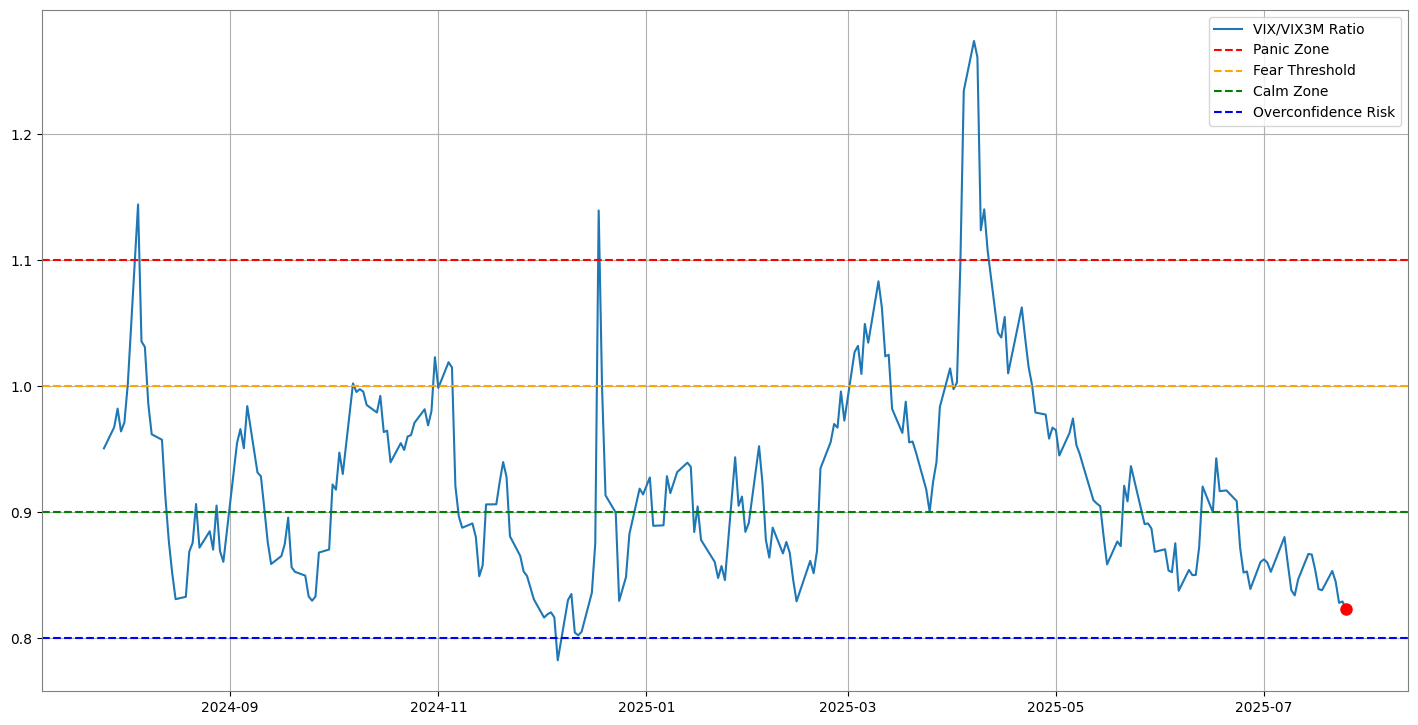

In [6]:
create_chart(df)

In [ ]:
from utils.chart import add_symbol_to_svg

add_symbol_to_svg("../output/data/vix_vix3m/chart.svg", "恐慌指数近月与远月比率")

## Video Script
[top](#contents)

In [10]:
def interpret_vix_vix3m_ratio_en(ratio):
    if ratio > 1.10:
        return {
            "zone": "Panic",
            "sentiment": "Short-term fear spike",
            "market_behavior": "Crisis or heavy selling pressure",
            "signal": "Contrarian long equity or prepare for VIX mean reversion",
            "interpretation": "This indicates a surge in short-term panic, typically seen during crises or strong market sell-offs.",
        }
    elif 1.00 < ratio <= 1.10:
        return {
            "zone": "Elevated Fear",
            "sentiment": "Defensive risk-off",
            "market_behavior": "Volatile, uncertain (e.g. macro events)",
            "signal": "Stay cautious or hedge equity exposure",
            "interpretation": "Reflects a defensive risk-off sentiment with increased volatility and uncertainty, often due to macroeconomic events.",
        }
    elif 0.90 < ratio <= 1.00:
        return {
            "zone": "Neutral",
            "sentiment": "Mixed outlook",
            "market_behavior": "Sideways market or chop",
            "signal": "No clear edge",
            "interpretation": "Indicates mixed market sentiment, with sideways consolidation or choppy price action being common.",
        }
    elif 0.80 < ratio <= 0.90:
        return {
            "zone": "Calm",
            "sentiment": "Complacent",
            "market_behavior": "Volatility suppression, bullish bias",
            "signal": "Favorable for short volatility strategies",
            "interpretation": "Suggests a calm market environment where volatility is subdued and the bias tends to favor bullish positioning.",
        }
    elif ratio <= 0.80:
        return {
            "zone": "Complacency Risk",
            "sentiment": "Overconfidence",
            "market_behavior": "Late-stage rally, melt-up",
            "signal": "Contrarian long VIX or reduce equity exposure",
            "interpretation": "Signals potential overconfidence in the market, often seen in late-stage bull runs or melt-up scenarios.",
        }

In [11]:
def interpret_vix_vix3m_ratio_zh(ratio):
    if ratio > 1.10:
        return {
            "zone": "恐慌区",
            "sentiment": "短期恐慌情绪激增",
            "market_behavior": "市场陷入危机或遭遇强烈抛售压力",
            "signal": "可考虑逆势做多股市，或准备VIX均值回归策略",
            "interpretation": "这表明市场出现短期恐慌情绪，典型特征为市场陷入危机或面临剧烈抛售压力。",
        }
    elif 1.00 < ratio <= 1.10:
        return {
            "zone": "恐惧区",
            "sentiment": "防御性避险情绪",
            "market_behavior": "市场波动剧烈，不确定性增加（如宏观事件）",
            "signal": "保持谨慎，或对股票头寸进行对冲",
            "interpretation": "这反映出市场正处于防御性避险状态，常见特征包括剧烈波动与不确定性上升。",
        }
    elif 0.90 < ratio <= 1.00:
        return {
            "zone": "中性区",
            "sentiment": "市场情绪分歧",
            "market_behavior": "横盘整理或震荡行情",
            "signal": "暂无明确交易优势",
            "interpretation": "说明市场情绪偏向观望或分歧，行情多表现为横盘整理或震荡波动。",
        }
    elif 0.80 < ratio <= 0.90:
        return {
            "zone": "平静区",
            "sentiment": "市场情绪安逸",
            "market_behavior": "波动率受压，市场偏多",
            "signal": "适合短波动策略操作",
            "interpretation": "反映出市场情绪趋于安逸，波动率受到抑制，整体倾向偏多。",
        }
    elif ratio <= 0.80:
        return {
            "zone": "自满区",
            "sentiment": "市场过度乐观",
            "market_behavior": "行情可能处于末升段或出现“融涨”",
            "signal": "可考虑逆势做多VIX，或适度降低股票敞口",
            "interpretation": "市场可能出现过度乐观情绪，常见于行情进入末升段，甚至出现“融涨”迹象。",
        }

In [12]:
last = df.iloc[-1]
ratio_value = last["Ratio"]
result = interpret_vix_vix3m_ratio_en(ratio_value)

print(f"Date: {last.name.strftime('%Y-%m-%d')}")
print(f"VIX: {last['VIX']}")
print(f"VIX3M: {last['VIX3M']}")
print(f"Ratio: {last['Ratio']}")
print(f"Interpretation for VIX/VXV = {ratio_value:.2f}")
print(f"  Zone: {result['zone']}")
print(f"  Sentiment: {result['sentiment']}")
print(f"  Market Behavior: {result['market_behavior']}")
print(f"  Potential Signal: {result['signal']}")

Date: 2025-07-25
VIX: 15.07
VIX3M: 18.3
Ratio: 0.8235
Interpretation for VIX/VXV = 0.82
  Zone: Calm
  Sentiment: Complacent
  Market Behavior: Volatility suppression, bullish bias
  Potential Signal: Favorable for short volatility strategies


In [13]:
result = interpret_vix_vix3m_ratio_zh(ratio_value)

data = {
    "name": "VIX近月与远月比值",
    "trading_day": last.name.strftime("%Y-%m-%d"),
    "interval": "1d",
    "vix_close": "{:.2f}".format(last["VIX"]),
    "vix3m_close": "{:.2f}".format(last["VIX3M"]),
    "ratio": "{:.2f}".format(last["Ratio"]),
    "zone": result["zone"],
    "sentiment": result["sentiment"],
    "market_behavior": result["market_behavior"],
    "interpretation": result["interpretation"],
}

In [14]:
data

{'name': 'VIX近月与远月比值',
 'trading_day': '2025-07-25',
 'interval': '1d',
 'vix_close': '15.07',
 'vix3m_close': '18.30',
 'ratio': '0.82',
 'zone': '平静区',
 'sentiment': '市场情绪安逸',
 'market_behavior': '波动率受压，市场偏多',
 'interpretation': '反映出市场情绪趋于安逸，波动率受到抑制，整体倾向偏多。'}

In [15]:
def vix_vix3m_video_script_en(c: VixVix3mTechnical):
    script = f"""
The VIX to VIX3M ratio stands at **{c.ratio}**, placing it in the **{c.zone} zone**.
This suggests {c.sentiment} in the market, with conditions typically marked by {c.market_behavior}.
"""
    return script.strip()

In [16]:
def vix_vix3m_video_script_zh(c: VixVix3mTechnical) -> str:
    script = f"""
当前恐慌指数近月与远月的比值为{c.ratio}，处于{c.zone}。
{c.interpretation}
"""
    return script.strip()

In [ ]:
from utils.script import save_script, save_technical

c = VixVix3mTechnical(**data)
script = vix_vix3m_video_script_zh(c)

filejson = "../output/data/vix_vix3m/technical.json"
save_technical(c, filejson)

filename = "../output/data/vix_vix3m/script.txt"
save_script(script, filename)

print(script)

当前恐慌指数近月与远月的比值为0.82，处于平静区。
反映出市场情绪趋于安逸，波动率受到抑制，整体倾向偏多。


当前恐慌指数近远比值为0.84，处于平静区。
反映出市场情绪趋于安逸，波动率受到抑制，整体倾向偏多。